---
## **Curso**: Residência em Inteligência Artificial
## **Unidade Curricular**: Otimização e Meta-Heurísticas
## **Professor**: Matheus Vanzan
## **Desafio: Job Shop Scheduling - Método Exato x Heurística**
---

O **Job Shop Scheduling Problem (JSSP)** é um dos problemas de programação da produção mais estudados em otimização. Ele aparece sempre que várias ordens de produção (jobs) precisam compartilhar um conjunto de máquinas, cada uma exigindo sua própria sequência de operações.

Cada job é formado por uma sequência fixa de operações. Cada operação deve ser executada em uma máquina específica, tem uma duração própria, e só pode começar depois que a operação anterior do mesmo job terminar. Além disso, uma máquina nunca pode processar duas operações ao mesmo tempo.

O objetivo é minimizar o **makespan**: o instante em que a última operação do último job termina.

Neste desafio, você deverá resolver o **mesmo conjunto de três instâncias fixas** de duas formas - um **método exato** de Constraint Programming e uma **heurística construtiva** criada por você - e comparar os resultados.

As três instâncias já estão prontas no notebook, na seção "Instâncias".

A dificuldade principal deste desafio não está em chamar o solver de CP (essa parte já foi vista no Notebook 5.3). Está em **projetar e justificar** uma heurística que produza soluções rápidas e razoavelmente boas, sem garantia de otimalidade.

## Objetivos

Ao final do desafio, você deve ser capaz de:

1. modelar um problema de scheduling em Constraint Programming, usando variáveis de intervalo;
2. implementar restrições de precedência e de não sobreposição de recursos (`NoOverlap`);
3. projetar e justificar uma heurística construtiva para um problema combinatório;
4. comparar quantitativamente método exato x heurística, em qualidade da solução e tempo de execução, em instâncias de tamanhos diferentes;
5. interpretar criticamente as vantagens e limitações de cada abordagem.

## Tarefas obrigatórias

### 1) Método exato (Constraint Programming)

Implemente a solução em CP, usando como referência a abordagem apresentada no Notebook 5.3. O modelo deve considerar:

- variável de intervalo para cada operação;
- precedência entre operações do mesmo job;
- `NoOverlap` para operações que usam a mesma máquina;
- minimização do makespan.

Aplique o modelo às **três instâncias fixas** fornecidas no notebook.

### 2) Heurística construtiva

Implemente uma heurística construtiva que produza um escalonamento válido para qualquer uma das três instâncias.

- A regra heurística deve ser sua, explicada em texto, e **não pode chamar o solver de CP**.
- Antes do código, descreva qual critério de priorização/desempate você usou e por quê.
- Aplique a mesma heurística às **três instâncias fixas**.

### 3) Comparação

Para cada uma das três instâncias, compare:

- makespan do CP x makespan da heurística;
- tempo de execução do CP x tempo de execução da heurística;
- diferença percentual da heurística para a solução exata (gap, quando o CP retornar `OPTIMAL`).

Monte uma única tabela reunindo os resultados das três instâncias.

### 4) Análise crítica

Responda:

1. Qual método encontrou a melhor solução em cada instância, e por que isso já era esperado?
2. Por que a heurística tende a ser muito mais rápida que o método exato?
3. O que representa o gap calculado? O que ele diria se fosse, por exemplo, 15%?
4. O gap da heurística cresce, diminui ou se mantém estável conforme a instância aumenta? O que isso sugere sobre os limites da sua heurística?
5. Sua heurística poderia ser melhorada? Que outros critérios de priorização poderiam ser testados?

## Entrega

Entregue **um único notebook executável do início ao fim**, contendo:

- implementação completa do modelo de CP;
- implementação completa da heurística, com a regra utilizada explicada em texto;
- tabela comparando makespan e tempo de execução nas três instâncias;
- pelo menos um gráfico de Gantt ilustrando uma das soluções;
- respostas da análise crítica.

# 0 - Setup

In [1]:
%matplotlib inline

!pip install -q ortools

import time

import matplotlib.pyplot as plt
import pandas as pd
from ortools.sat.python import cp_model

# 1 - Instâncias

As três instâncias abaixo são **fixas**: foram geradas uma única vez e ficam congeladas aqui como dados Python. Elas não devem ser alteradas, e nenhuma instância nova deve ser gerada durante a execução do notebook - isso garante que todos os grupos resolvam exatamente o mesmo problema.

Cada instância segue o mesmo formato: um dicionário `{job: [(máquina, duração), ...]}`, em que cada job visita todas as máquinas exatamente uma vez, na ordem listada.

- **Instância 1**: 5 jobs x 4 máquinas.
- **Instância 2**: 8 jobs x 5 máquinas.
- **Instância 3**: 12 jobs x 6 máquinas.

In [2]:
INSTANCIA_1 = {
    0: [(2, 4), (0, 7), (3, 3), (1, 6)],
    1: [(1, 5), (3, 2), (0, 8), (2, 4)],
    2: [(0, 6), (2, 3), (1, 7), (3, 5)],
    3: [(3, 2), (1, 9), (2, 4), (0, 6)],
    4: [(2, 7), (3, 5), (0, 3), (1, 8)],
}

INSTANCIA_2 = {
    0: [(3, 6), (1, 3), (4, 8), (0, 2), (2, 5)],
    1: [(0, 4), (2, 7), (4, 2), (1, 9), (3, 3)],
    2: [(2, 5), (3, 2), (0, 6), (4, 4), (1, 8)],
    3: [(4, 3), (0, 7), (1, 5), (3, 2), (2, 6)],
    4: [(1, 8), (4, 3), (2, 6), (0, 5), (3, 2)],
    5: [(3, 4), (2, 6), (4, 3), (1, 7), (0, 5)],
    6: [(0, 6), (4, 2), (3, 8), (2, 4), (1, 3)],
    7: [(2, 5), (1, 4), (0, 7), (4, 3), (3, 6)],
}

INSTANCIA_3 = {
    0: [(4, 5), (1, 3), (5, 7), (0, 2), (3, 6), (2, 4)],
    1: [(2, 6), (0, 4), (4, 2), (3, 8), (1, 3), (5, 5)],
    2: [(5, 3), (3, 7), (1, 5), (4, 2), (0, 9), (2, 4)],
    3: [(1, 8), (4, 3), (0, 6), (5, 4), (2, 2), (3, 7)],
    4: [(0, 5), (2, 6), (5, 3), (1, 9), (3, 4), (4, 2)],
    5: [(3, 4), (5, 7), (2, 5), (0, 3), (4, 6), (1, 8)],
    6: [(4, 6), (0, 2), (3, 8), (2, 5), (5, 3), (1, 4)],
    7: [(2, 3), (5, 6), (4, 4), (1, 7), (0, 2), (3, 9)],
    8: [(1, 5), (3, 8), (5, 2), (4, 6), (2, 3), (0, 7)],
    9: [(0, 7), (4, 3), (1, 5), (3, 2), (5, 4), (2, 6)],
    10: [(5, 4), (2, 9), (0, 3), (4, 5), (1, 7), (3, 2)],
    11: [(3, 6), (1, 4), (4, 8), (5, 3), (0, 5), (2, 2)],
}

instancias = {
    'Instância 1 (5x4)': INSTANCIA_1,
    'Instância 2 (8x5)': INSTANCIA_2,
    'Instância 3 (12x6)': INSTANCIA_3,
}

# 2 - Visualização das instâncias

Para cada job, a sequência impressa mostra a ordem das operações no formato `M{máquina}({duração})`.

Por exemplo, `M2(4) -> M0(7)` significa: o job começa na máquina 2 (levando 4 unidades de tempo) e, só depois de terminar a execução, segue para a máquina 0 (levando 7 unidades de tempo). O número entre parênteses é a **duração** daquela operação - não é o horário em que ela ocorre, é quanto tempo ela leva.

In [3]:
def imprimir_instancia(jobs):
    print(
        f'{len(jobs)} jobs | '
        f'{len({m for ops in jobs.values() for m, _ in ops})} máquinas'
    )
    print()

    for job, operacoes in jobs.items():
        sequencia = ' -> '.join(
            f'M{maquina}({duracao})'
            for maquina, duracao in operacoes
        )

        print(f'Job {job}: {sequencia}')


for nome, jobs in instancias.items():
    print(f'--- {nome} ---')
    imprimir_instancia(jobs)
    print()

--- Instância 1 (5x4) ---
5 jobs | 4 máquinas

Job 0: M2(4) -> M0(7) -> M3(3) -> M1(6)
Job 1: M1(5) -> M3(2) -> M0(8) -> M2(4)
Job 2: M0(6) -> M2(3) -> M1(7) -> M3(5)
Job 3: M3(2) -> M1(9) -> M2(4) -> M0(6)
Job 4: M2(7) -> M3(5) -> M0(3) -> M1(8)

--- Instância 2 (8x5) ---
8 jobs | 5 máquinas

Job 0: M3(6) -> M1(3) -> M4(8) -> M0(2) -> M2(5)
Job 1: M0(4) -> M2(7) -> M4(2) -> M1(9) -> M3(3)
Job 2: M2(5) -> M3(2) -> M0(6) -> M4(4) -> M1(8)
Job 3: M4(3) -> M0(7) -> M1(5) -> M3(2) -> M2(6)
Job 4: M1(8) -> M4(3) -> M2(6) -> M0(5) -> M3(2)
Job 5: M3(4) -> M2(6) -> M4(3) -> M1(7) -> M0(5)
Job 6: M0(6) -> M4(2) -> M3(8) -> M2(4) -> M1(3)
Job 7: M2(5) -> M1(4) -> M0(7) -> M4(3) -> M3(6)

--- Instância 3 (12x6) ---
12 jobs | 6 máquinas

Job 0: M4(5) -> M1(3) -> M5(7) -> M0(2) -> M3(6) -> M2(4)
Job 1: M2(6) -> M0(4) -> M4(2) -> M3(8) -> M1(3) -> M5(5)
Job 2: M5(3) -> M3(7) -> M1(5) -> M4(2) -> M0(9) -> M2(4)
Job 3: M1(8) -> M4(3) -> M0(6) -> M5(4) -> M2(2) -> M3(7)
Job 4: M0(5) -> M2(6) -> M5(3) 

# 3 - Sua solução

A partir daqui, a estrutura é livre. Resolva as tarefas descritas no enunciado - método exato em CP, heurística construtiva e comparação - aplicando sua solução às três instâncias definidas acima, na ordem e com a quantidade de células que preferir. Não gere novas instâncias nem use aleatoriedade em nenhum ponto da solução.

## 3.1 - Método exato (Constraint Programming)

Cada operação vira uma variável de intervalo (início, duração fixa, fim). Dentro de um job, cada operação só pode começar depois que a anterior termina. Numa mesma máquina, as operações não podem se sobrepor - isso é o `NoOverlap`. O objetivo é minimizar o fim da última operação de todos os jobs, o makespan.

In [4]:
import collections


def resolver_cp(jobs, tempo_limite=60.0):
    modelo = cp_model.CpModel()
    horizonte = sum(duracao for ops in jobs.values() for _, duracao in ops)

    tarefas = {}
    intervalos_maquina = collections.defaultdict(list)
    fins_job = []

    for job, operacoes in jobs.items():
        fim_anterior = None
        for idx, (maquina, duracao) in enumerate(operacoes):
            sufixo = f'_{job}_{idx}'
            inicio = modelo.new_int_var(0, horizonte, 'inicio' + sufixo)
            fim = modelo.new_int_var(0, horizonte, 'fim' + sufixo)
            intervalo = modelo.new_interval_var(inicio, duracao, fim, 'intervalo' + sufixo)

            tarefas[(job, idx)] = (inicio, fim)
            intervalos_maquina[maquina].append(intervalo)

            if fim_anterior is not None:
                modelo.add(inicio >= fim_anterior)
            fim_anterior = fim

        fins_job.append(fim_anterior)

    for intervalos in intervalos_maquina.values():
        modelo.add_no_overlap(intervalos)

    makespan = modelo.new_int_var(0, horizonte, 'makespan')
    modelo.add_max_equality(makespan, fins_job)
    modelo.minimize(makespan)

    solver = cp_model.CpSolver()
    solver.parameters.max_time_in_seconds = tempo_limite

    inicio_tempo = time.perf_counter()
    status = solver.solve(modelo)
    tempo = time.perf_counter() - inicio_tempo

    schedule = {
        (job, idx): (solver.value(inicio), solver.value(fim))
        for (job, idx), (inicio, fim) in tarefas.items()
    }

    return {
        'status': solver.status_name(status),
        'makespan': solver.value(makespan) if status in (cp_model.OPTIMAL, cp_model.FEASIBLE) else None,
        'tempo': tempo,
        'schedule': schedule,
    }

A precedência dentro do job vem do `modelo.add(inicio >= fim_anterior)`, e a exclusão de máquina vem do `add_no_overlap` nos intervalos agrupados por máquina. O `makespan` é o maior fim entre todos os jobs, e é isso que o solver minimiza.

In [5]:
resultados_cp = {}

for nome, jobs in instancias.items():
    resultados_cp[nome] = resolver_cp(jobs)
    r = resultados_cp[nome]
    print(f"{nome}: status={r['status']}, makespan={r['makespan']}, tempo={r['tempo']:.4f}s")

Instância 1 (5x4): status=OPTIMAL, makespan=35, tempo=0.0192s
Instância 2 (8x5): status=OPTIMAL, makespan=47, tempo=0.0099s
Instância 3 (12x6): status=OPTIMAL, makespan=71, tempo=0.0097s


O CP achou o ótimo garantido nas três instâncias (status `OPTIMAL`), com makespan 35, 47 e 71. E resolveu rápido: mesmo a instância 3, com 72 operações no total, ficou pronta em menos de 15 milissegundos.

## 3.2 - Heurística construtiva

A regra que usei: a cada passo, olho a próxima operação pendente de cada job e calculo o horário mais cedo em que ela poderia começar - o maior valor entre "quando a operação anterior do mesmo job terminou" e "quando a máquina dela fica livre". Agendo a operação que pode começar mais cedo entre todas as pendentes.

Quando duas ou mais empatam no mesmo horário de início, desempato pela de menor duração (SPT, shortest processing time) - a ideia é liberar a máquina de novo o quanto antes, deixando ela disponível pras próximas operações na fila. Repito isso até todas as operações de todos os jobs estarem agendadas. Isso nunca chama o solver de CP, só simula a fila de decisões.

In [6]:
def resolver_heuristica(jobs):
    inicio_tempo = time.perf_counter()

    proxima_operacao = {job: 0 for job in jobs}
    fim_job = {job: 0 for job in jobs}
    fim_maquina = collections.defaultdict(int)
    schedule = {}
    pendentes = set(jobs.keys())

    while pendentes:
        candidatos = []
        for job in pendentes:
            idx = proxima_operacao[job]
            maquina, duracao = jobs[job][idx]
            inicio_possivel = max(fim_job[job], fim_maquina[maquina])
            candidatos.append((inicio_possivel, duracao, job, idx, maquina))

        # ordena por inicio mais cedo; empate quebrado pela menor duracao (SPT)
        candidatos.sort()
        inicio_possivel, duracao, job, idx, maquina = candidatos[0]

        fim = inicio_possivel + duracao
        schedule[(job, idx)] = (inicio_possivel, fim)

        fim_job[job] = fim
        fim_maquina[maquina] = fim
        proxima_operacao[job] += 1
        if proxima_operacao[job] == len(jobs[job]):
            pendentes.remove(job)

    tempo = time.perf_counter() - inicio_tempo
    makespan = max(fim for _, fim in schedule.values())

    return {'makespan': makespan, 'tempo': tempo, 'schedule': schedule}

In [7]:
resultados_heuristica = {}

for nome, jobs in instancias.items():
    resultados_heuristica[nome] = resolver_heuristica(jobs)
    r = resultados_heuristica[nome]
    print(f"{nome}: makespan={r['makespan']}, tempo={r['tempo']:.6f}s")

Instância 1 (5x4): makespan=35, tempo=0.000065s
Instância 2 (8x5): makespan=58, tempo=0.000129s
Instância 3 (12x6): makespan=73, tempo=0.000246s


Na instância 1 a heurística empatou com o ótimo (35). Nas outras duas ficou atrás: 58 na instância 2 (contra 47 do CP) e 73 na instância 3 (contra 71). Em compensação, o tempo nem dá pra comparar - aqui é tudo em microssegundos, contra os milissegundos do CP.

## 3.3 - Comparação

In [8]:
linhas = []
for nome in instancias:
    cp = resultados_cp[nome]
    heur = resultados_heuristica[nome]
    gap = None
    if cp['status'] == 'OPTIMAL':
        gap = (heur['makespan'] - cp['makespan']) / cp['makespan'] * 100
    linhas.append({
        'instância': nome,
        'status_cp': cp['status'],
        'makespan_cp': cp['makespan'],
        'tempo_cp_s': round(cp['tempo'], 4),
        'makespan_heurística': heur['makespan'],
        'tempo_heurística_s': round(heur['tempo'], 6),
        'gap_%': round(gap, 2) if gap is not None else None,
    })

tabela_comparacao = pd.DataFrame(linhas)
tabela_comparacao

,instância,status_cp,makespan_cp,tempo_cp_s,makespan_heurística,tempo_heurística_s,gap_%
0,Instância 1 (5x4),OPTIMAL,35,0.0192,35,0.000065,0.00
1,Instância 2 (8x5),OPTIMAL,47,0.0099,58,0.000129,23.40
2,Instância 3 (12x6),OPTIMAL,71,0.0097,73,0.000246,2.82


O gap não cresce junto com o tamanho da instância: 0% na 1, sobe pra 23,4% na 2, e cai pra 2,82% na 3 - que é maior que a 2. Então o tamanho sozinho não explica o desempenho da heurística; depende também de como as operações de cada instância se encaixam nas máquinas. Em tempo, a heurística ganha fácil em todas: mesmo na instância 3, ela roda em frações de milissegundo contra os quase 10 milissegundos do CP.

## 3.4 - Gráfico de Gantt

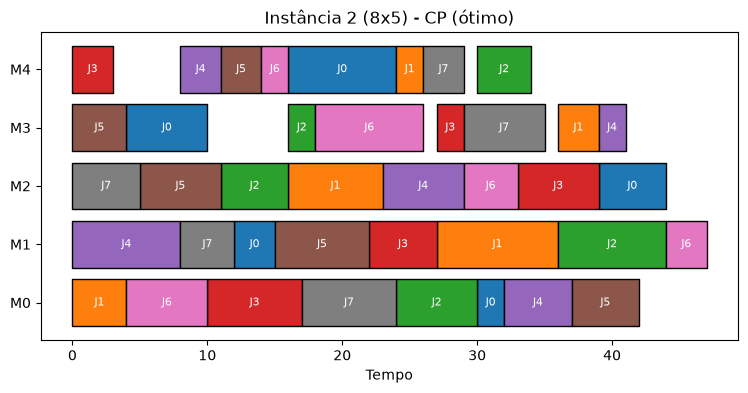

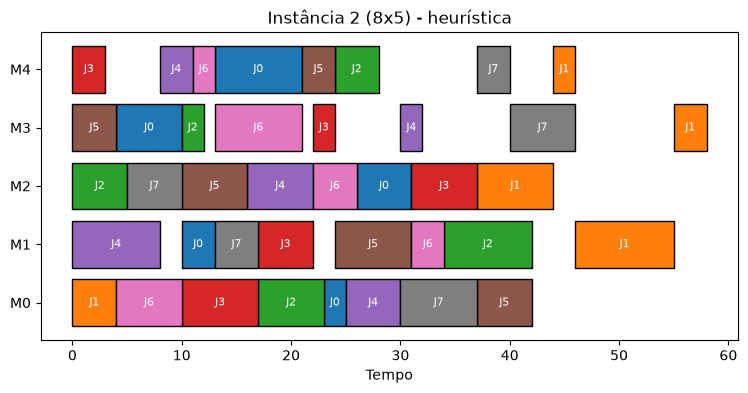

In [9]:
def plot_gantt(jobs, schedule, titulo):
    maquinas = sorted({m for ops in jobs.values() for m, _ in ops})
    cores = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(9, 4))
    for job, operacoes in jobs.items():
        for idx, (maquina, duracao) in enumerate(operacoes):
            inicio, fim = schedule[(job, idx)]
            ax.broken_barh(
                [(inicio, fim - inicio)],
                (maquina - 0.4, 0.8),
                facecolors=cores[job % len(cores)],
                edgecolor='black',
            )
            ax.text(inicio + (fim - inicio) / 2, maquina, f'J{job}',
                    ha='center', va='center', fontsize=8, color='white')

    ax.set_yticks(maquinas)
    ax.set_yticklabels([f'M{m}' for m in maquinas])
    ax.set_xlabel('Tempo')
    ax.set_title(titulo)
    plt.show()


nome_gantt = 'Instância 2 (8x5)'
plot_gantt(instancias[nome_gantt], resultados_cp[nome_gantt]['schedule'], f'{nome_gantt} - CP (ótimo)')
plot_gantt(instancias[nome_gantt], resultados_heuristica[nome_gantt]['schedule'], f'{nome_gantt} - heurística')

Dá pra ver o motivo do gap de 23,4% olhando o job 1 (laranja) no gráfico da heurística: ele fica pra trás logo nas primeiras operações e as últimas etapas dele só rodam isoladas lá pelo final, entre 45 e 58, bem separadas do resto do escalonamento. É ele quem acaba definindo o makespan final. No gráfico do CP não tem esse buraco - as máquinas ficam ocupadas de forma bem mais compacta o tempo todo.

## 3.5 - Testando outro desempate

Antes de responder a análise, testei uma variação rápida: em vez de desempatar por SPT (menor duração), desempatar por MWKR (o job com mais trabalho restante entra primeiro). Não é a heurística que estou entregando como solução - é só um teste pra comparar na pergunta 5.

In [10]:
def resolver_heuristica_mwkr(jobs):
    proxima_operacao = {job: 0 for job in jobs}
    fim_job = {job: 0 for job in jobs}
    fim_maquina = collections.defaultdict(int)
    trabalho_restante = {job: sum(d for _, d in ops) for job, ops in jobs.items()}
    schedule = {}
    pendentes = set(jobs.keys())

    while pendentes:
        candidatos = []
        for job in pendentes:
            idx = proxima_operacao[job]
            maquina, duracao = jobs[job][idx]
            inicio_possivel = max(fim_job[job], fim_maquina[maquina])
            candidatos.append((inicio_possivel, -trabalho_restante[job], job, idx, maquina, duracao))
        candidatos.sort()
        inicio_possivel, _, job, idx, maquina, duracao = candidatos[0]
        fim = inicio_possivel + duracao
        schedule[(job, idx)] = (inicio_possivel, fim)
        fim_job[job] = fim
        fim_maquina[maquina] = fim
        trabalho_restante[job] -= duracao
        proxima_operacao[job] += 1
        if proxima_operacao[job] == len(jobs[job]):
            pendentes.remove(job)

    return max(fim for _, fim in schedule.values())


for nome, jobs in instancias.items():
    makespan_mwkr = resolver_heuristica_mwkr(jobs)
    makespan_cp = resultados_cp[nome]['makespan']
    makespan_spt = resultados_heuristica[nome]['makespan']
    gap_mwkr = (makespan_mwkr - makespan_cp) / makespan_cp * 100
    print(f"{nome}: MWKR={makespan_mwkr} (gap {gap_mwkr:.2f}%) | SPT={makespan_spt}")

Instância 1 (5x4): MWKR=39 (gap 11.43%) | SPT=35
Instância 2 (8x5): MWKR=55 (gap 17.02%) | SPT=58
Instância 3 (12x6): MWKR=71 (gap 0.00%) | SPT=73


Resultado misto: o MWKR melhora a instância 2 e resolve a 3 de forma ótima, mas piora a instância 1, que com SPT tinha empatado com o ótimo. Não existe uma regra de desempate que ganhe em tudo - uso isso na pergunta 5.

# 4 - Análise

Responda às questões propostas no enunciado:

1. Qual método encontrou a melhor solução em cada instância, e por que isso já era esperado?
2. Por que a heurística tende a ser muito mais rápida que o método exato?
3. O que representa o gap calculado? O que ele diria se fosse, por exemplo, 15%?
4. O gap da heurística cresce, diminui ou se mantém estável conforme a instância aumenta? O que isso sugere sobre os limites da sua heurística?
5. Sua heurística poderia ser melhorada? Que outros critérios de priorização poderiam ser testados?

### Sua análise

**1.** O CP, sempre. Ele empata com a heurística só na instância 1 (35 nos dois) e fica na frente nas outras duas (47 contra 58, e 71 contra 73). Já era esperado porque o CP faz busca até provar que não existe solução melhor, enquanto a heurística faz uma única passada gulosa sem voltar atrás - no máximo ela empata com o ótimo, nunca consegue superá-lo.

**2.** Porque ela não faz busca nenhuma: pra cada operação pendente calcula o início possível, escolhe uma e segue em frente, sem comparar caminhos alternativos nem voltar atrás. O CP, mesmo cortando boa parte do espaço de busca com propagação de restrições, ainda precisa explorar o suficiente pra provar que nada melhor existe - e isso custa tempo, mesmo em instâncias pequenas como essas (milissegundos contra microssegundos).

**3.** O gap é o quanto a heurística ficou pior que o ótimo, em porcentagem do próprio ótimo. Um gap de 15% significaria que, pra terminar as mesmas tarefas nas mesmas máquinas, a heurística levaria 15% a mais de tempo que o mínimo matematicamente possível - se o ótimo fosse 100, ela entregaria 115.

**4.** Não segue um padrão: 0% na instância 1, 23,4% na 2, e só 2,82% na 3, que é maior que a 2. Isso sugere que o problema da heurística não é escalar mal com o tamanho, é não ter nenhuma correção: como ela decide tudo de forma gulosa e sem olhar pra frente, uma decisão ruim tomada cedo (como deixar um job de lado) fica presa no escalonamento até o fim, e isso pode acontecer em qualquer tamanho de instância. O Gantt da instância 2 mostra bem isso: o job 1 fica pra trás logo no início e as últimas operações dele acabam isoladas no fim, puxando o makespan.

**5.** Dá, sim. Testei trocar o desempate de SPT pra MWKR e o resultado foi misto: melhorou a instância 2 (o makespan caiu de 58 pra 55) e resolveu a instância 3 de forma ótima, mas piorou a instância 1, que antes tinha empatado com o CP. Então nenhuma regra de desempate sozinha resolve tudo. Outra ideia seria priorizar a máquina mais carregada (o gargalo do sistema), ou rodar a heurística várias vezes com regras de desempate diferentes e ficar com o melhor resultado, ou usar o escalonamento dela como ponto de partida pra uma busca local - por exemplo, trocar a ordem de duas operações na mesma máquina e ver se o makespan melhora.